# Bank Marketing Dataset - Machine Learning
This notebook builds a production-quality ML pipeline and compares six models.

We train two scenarios:
- **With `duration`** for post-call analysis.
- **Without `duration`** for realistic pre-campaign prediction and deployment.

We also optimize decision thresholds to meet precision/recall requirements.

## 1. Load Cleaned Data
We use the cleaned dataset generated by the EDA notebook.

In [1]:
# Core libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import Markdown, display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

sns.set_theme(style="whitegrid")

# Shared color palette for charts
COLOR_PALETTE = ["#1F6FEB", "#2EC4B6", "#F4A259", "#9B5DE5", "#E63946", "#0B2545"]
OUTCOME_PALETTE = {"no": "#0B2545", "yes": "#2EC4B6"}
sns.set_palette(COLOR_PALETTE)


# Resolve project root and load the cleaned dataset (run the EDA notebook first)
project_root = Path.cwd()
if not (project_root / "cleaned_bank_dataset.csv").exists():
    project_root = project_root.parent

data_path = project_root / "cleaned_bank_dataset.csv"
df = pd.read_csv(data_path)
y = (df["y"] == "yes").astype(int)

# Two scenarios: with duration (post-call) and without duration (pre-campaign)
X_with_duration = df.drop(columns=["y"])
X_without_duration = df.drop(columns=["y", "duration"])

# Shared train/test split for both scenarios
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42, stratify=y
)
print("Train size:", len(train_idx), "Test size:", len(test_idx))


Train size: 36168 Test size: 9043


## 2. Preprocessing Pipeline
We use `ColumnTransformer` and `Pipeline` for clean, reproducible preprocessing.

In [2]:
def build_preprocessor(X):
    cat_cols = X.select_dtypes(include=["object", "category"]).columns
    num_cols = X.select_dtypes(exclude=["object", "category"]).columns

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer(transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric="logloss", random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42)
}

# SVC(probability=True) is too slow on ~36K rows, so SVM trains on a stratified
# 6,000-row subsample and is still evaluated on the full test set.
SVM_SAMPLE_SIZE = 6000

def get_training_data(X_train, y_train, model_name, sample_size=SVM_SAMPLE_SIZE, random_state=42):
    """Return a stratified subsample for SVM, or the full data for other models."""
    if model_name == "SVM" and len(X_train) > sample_size:
        X_sample, _, y_sample, _ = train_test_split(
            X_train, y_train,
            train_size=sample_size,
            stratify=y_train,
            random_state=random_state
        )
        return X_sample, y_sample
    return X_train, y_train


## 3. Model Training and Evaluation
We train six models for two scenarios: with duration (post-call) and without duration (pre-campaign).

**Note on SVM:** `SVC` with `probability=True` has roughly O(n^2)-O(n^3) training complexity. On this ~36K-row training set this is computationally impractical, so SVM is fit on a stratified 6,000-row subsample (a standard practice for kernel SVMs on large datasets), while it is always evaluated on the full held-out test set.

In [3]:
def evaluate_models(X, y, train_idx, test_idx):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    preprocessor = build_preprocessor(X_train)
    results = []
    trained = {}

    for name, model in models.items():
        clf = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ])
        X_fit, y_fit = get_training_data(X_train, y_train, name)
        clf.fit(X_fit, y_fit)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1]
        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC_AUC": roc_auc_score(y_test, y_prob)
        })
        trained[name] = clf

    results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
    best_model_name = results_df.iloc[0]["Model"]
    return results_df, trained, best_model_name, X_train, X_test, y_train, y_test

# Scenario A: With duration (post-call analysis)
results_with, trained_with, best_with, Xtr_with, Xte_with, ytr_with, yte_with = evaluate_models(
    X_with_duration, y, train_idx, test_idx
)

# Scenario B: Without duration (pre-campaign prediction)
results_without, trained_without, best_without, Xtr_without, Xte_without, ytr_without, yte_without = evaluate_models(
    X_without_duration, y, train_idx, test_idx
)

display(results_with.head())
display(results_without.head())

scenario_comparison = pd.DataFrame([
    {
        "Scenario": "With duration",
        "Best Model": best_with,
        "Accuracy": results_with.iloc[0]["Accuracy"],
        "Precision": results_with.iloc[0]["Precision"],
        "Recall": results_with.iloc[0]["Recall"],
        "F1": results_with.iloc[0]["F1"],
        "ROC_AUC": results_with.iloc[0]["ROC_AUC"],
        "Business Use Case": "Post-call analysis"
    },
    {
        "Scenario": "Without duration",
        "Best Model": best_without,
        "Accuracy": results_without.iloc[0]["Accuracy"],
        "Precision": results_without.iloc[0]["Precision"],
        "Recall": results_without.iloc[0]["Recall"],
        "F1": results_without.iloc[0]["F1"],
        "ROC_AUC": results_without.iloc[0]["ROC_AUC"],
        "Business Use Case": "Pre-campaign prediction"
    }
])
display(scenario_comparison)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,XGBoost,0.900476,0.604775,0.431002,0.503311,0.915480
2,Random Forest,0.900033,0.618098,0.380907,0.471345,0.912435
0,Logistic Regression,0.899370,0.628920,0.341210,0.442402,0.899451
5,SVM,0.894836,0.700375,0.176749,0.282264,0.864413
4,KNN,0.894504,0.584416,0.340265,0.430108,0.828025


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,XGBoost,0.901139,0.610215,0.429112,0.503885,0.913997
2,Random Forest,0.900033,0.645283,0.323251,0.430730,0.907227
0,Logistic Regression,0.895278,0.602588,0.308129,0.407755,0.868180
5,SVM,0.894062,0.686567,0.173913,0.277526,0.866886
4,KNN,0.893951,0.602911,0.274102,0.376868,0.785603


,Scenario,Best Model,Accuracy,Precision,Recall,F1,ROC_AUC,Business Use Case
0,With duration,XGBoost,0.900476,0.604775,0.431002,0.503311,0.915480,Post-call analysis
1,Without duration,XGBoost,0.901139,0.610215,0.429112,0.503885,0.913997,Pre-campaign prediction


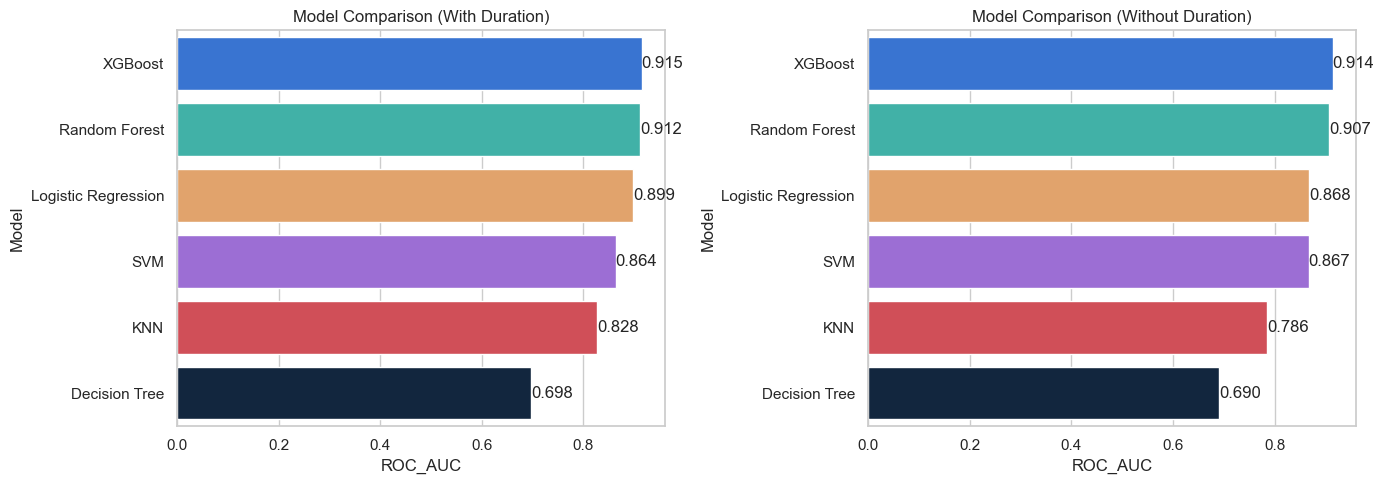

Including duration improves ROC-AUC, but duration is only known after a call ends. The no-duration model is used for pre-campaign targeting.

In [4]:
# Plot model comparison for both scenarios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax0 = sns.barplot(data=results_with, x="ROC_AUC", y="Model", hue="Model", palette=COLOR_PALETTE, legend=False, ax=axes[0])
for container in ax0.containers:
    ax0.bar_label(container, fmt="%.3f")
axes[0].set_title("Model Comparison (With Duration)")
ax1 = sns.barplot(data=results_without, x="ROC_AUC", y="Model", hue="Model", palette=COLOR_PALETTE, legend=False, ax=axes[1])
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.3f")
axes[1].set_title("Model Comparison (Without Duration)")
plt.tight_layout()
plt.show()

display(Markdown(
    "Including duration improves ROC-AUC, but duration is only known after a call ends. "
    "The no-duration model is used for pre-campaign targeting."
))


## Model Validation and Generalization
We use stratified train/test split and stratified K-fold cross-validation. This section explains overfitting, underfitting, and whether the final model generalizes well.

In [5]:
# Model validation and generalization (no-duration scenario)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
validation_rows = []

for name, model in models.items():
    preprocessor = build_preprocessor(Xtr_without)
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    X_fit, y_fit = get_training_data(Xtr_without, ytr_without, name)
    clf.fit(X_fit, y_fit)
    train_prob = clf.predict_proba(X_fit)[:, 1]
    test_prob = clf.predict_proba(Xte_without)[:, 1]
    train_score = roc_auc_score(y_fit, train_prob)
    test_score = roc_auc_score(yte_without, test_prob)
    if name == "SVM":
        X_cv, y_cv = get_training_data(X_without_duration, y, name)
        cv_scores = cross_val_score(clf, X_cv, y_cv, cv=skf, scoring="roc_auc")
    else:
        cv_scores = cross_val_score(clf, X_without_duration, y, cv=skf, scoring="roc_auc")
    overfit_gap = train_score - test_score
    overfit_risk = "High" if overfit_gap > 0.05 else "Low"
    validation_rows.append({
        "Model": name,
        "Train Score": train_score,
        "Test Score": test_score,
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Overfitting Risk": overfit_risk
    })

validation_df = pd.DataFrame(validation_rows).sort_values("Test Score", ascending=False)
display(validation_df)
display(Markdown(
    "A large train-test gap signals overfitting; consistent CV scores indicate "
    "the model generalizes well to unseen data."
))


,Model,Train Score,Test Score,CV Mean,CV Std,Overfitting Risk
3,XGBoost,0.977837,0.913997,0.919582,0.001335,High
2,Random Forest,1.000000,0.907227,0.909098,0.002999,High
0,Logistic Regression,0.872364,0.868180,0.870082,0.005903,Low
5,SVM,0.954348,0.866886,0.869710,0.020740,High
4,KNN,0.948505,0.785603,0.777466,0.010893,High
1,Decision Tree,1.000000,0.690189,0.687210,0.010096,High


A large train-test gap signals overfitting; consistent CV scores indicate the model generalizes well to unseen data.

## Hyperparameter Tuning
We use `GridSearchCV` for Random Forest, XGBoost, and SVM. We compare metrics before and after tuning.

In [6]:
def evaluate_pipeline(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

# Baseline performance (no-duration scenario)
baseline_metrics = {}
for name, model in {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric="logloss", random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}.items():
    preprocessor = build_preprocessor(Xtr_without)
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    X_fit, y_fit = get_training_data(Xtr_without, ytr_without, name)
    pipeline.fit(X_fit, y_fit)
    baseline_metrics[name] = evaluate_pipeline(pipeline, Xte_without, yte_without)

# Random Forest tuning
rf_pipeline = Pipeline(steps=[
    ("preprocessor", build_preprocessor(Xtr_without)),
    ("model", RandomForestClassifier(random_state=42))
])
rf_params = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [6, 10],
    "model__min_samples_split": [2, 5]
}
rf_grid = GridSearchCV(rf_pipeline, rf_params, cv=3, scoring="roc_auc", n_jobs=-1)
rf_grid.fit(Xtr_without, ytr_without)

# XGBoost tuning
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", build_preprocessor(Xtr_without)),
    ("model", xgb.XGBClassifier(eval_metric="logloss", random_state=42))
])
xgb_params = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1]
}
xgb_grid = GridSearchCV(xgb_pipeline, xgb_params, cv=3, scoring="roc_auc", n_jobs=-1)
xgb_grid.fit(Xtr_without, ytr_without)

# SVM tuning (on the stratified subsample)
svm_pipeline = Pipeline(steps=[
    ("preprocessor", build_preprocessor(Xtr_without)),
    ("model", SVC(probability=True, random_state=42))
])
svm_params = {
    "model__C": [0.5, 1, 5],
    "model__gamma": ["scale", "auto"]
}
svm_grid = GridSearchCV(svm_pipeline, svm_params, cv=3, scoring="roc_auc", n_jobs=-1)
X_svm_fit, y_svm_fit = get_training_data(Xtr_without, ytr_without, "SVM")
svm_grid.fit(X_svm_fit, y_svm_fit)

tuned_models = {
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_
}

after_metrics = {name: evaluate_pipeline(model, Xte_without, yte_without) for name, model in tuned_models.items()}

tuning_table = []
for name in ["Random Forest", "XGBoost", "SVM"]:
    tuning_table.append({
        "Model": name,
        "Before Accuracy": baseline_metrics[name]["Accuracy"],
        "After Accuracy": after_metrics[name]["Accuracy"],
        "Before Precision": baseline_metrics[name]["Precision"],
        "After Precision": after_metrics[name]["Precision"],
        "Before Recall": baseline_metrics[name]["Recall"],
        "After Recall": after_metrics[name]["Recall"],
        "Before F1": baseline_metrics[name]["F1"],
        "After F1": after_metrics[name]["F1"],
        "Before ROC_AUC": baseline_metrics[name]["ROC_AUC"],
        "After ROC_AUC": after_metrics[name]["ROC_AUC"]
    })

tuning_df = pd.DataFrame(tuning_table)
display(tuning_df)
print("Best RF params:", rf_grid.best_params_)
print("Best XGB params:", xgb_grid.best_params_)
print("Best SVM params:", svm_grid.best_params_)
display(Markdown("GridSearchCV (cv=3, scoring=ROC-AUC) tunes each model's key hyperparameters."))


,Model,Before Accuracy,After Accuracy,Before Precision,After Precision,Before Recall,After Recall,Before F1,After F1,Before ROC_AUC,After ROC_AUC
0,Random Forest,0.900033,0.895831,0.645283,0.726562,0.323251,0.175803,0.430730,0.283105,0.907227,0.901965
1,XGBoost,0.901139,0.905120,0.610215,0.647929,0.429112,0.413989,0.503885,0.505190,0.913997,0.920494
2,SVM,0.894062,0.894062,0.686567,0.671233,0.173913,0.185255,0.277526,0.290370,0.866886,0.880034


Best RF params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best XGB params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 300}
Best SVM params: {'model__C': 1, 'model__gamma': 'auto'}


GridSearchCV (cv=3, scoring=ROC-AUC) tunes each model's key hyperparameters.

## Classification Threshold Optimization
We tune the classification threshold to satisfy precision and recall requirements and maximize F1 score.

Best tuned model for thresholding: XGBoost


,threshold,accuracy,precision,recall,f1,roc_auc,tp,tn,fp,fn
0,0.10,0.822404,0.387889,0.896030,0.541405,0.920494,948,6489,1496,110
1,0.15,0.855579,0.437437,0.819471,0.570395,0.920494,867,6870,1115,191
2,0.20,0.877585,0.485647,0.783554,0.599638,0.920494,829,7107,878,229
3,0.25,0.889749,0.520374,0.736295,0.609785,0.920494,779,7267,718,279
4,0.30,0.897600,0.550691,0.677694,0.607627,0.920494,717,7400,585,341
5,0.35,0.900476,0.569420,0.612476,0.590164,0.920494,648,7495,490,410
6,0.40,0.902908,0.593168,0.541588,0.566206,0.920494,573,7592,393,485
7,0.45,0.905009,0.620606,0.483932,0.543813,0.920494,512,7672,313,546
8,0.50,0.905120,0.647929,0.413989,0.505190,0.920494,438,7747,238,620
9,0.55,0.905562,0.686813,0.354442,0.467581,0.920494,375,7814,171,683


Selected threshold: 0.25000000000000006


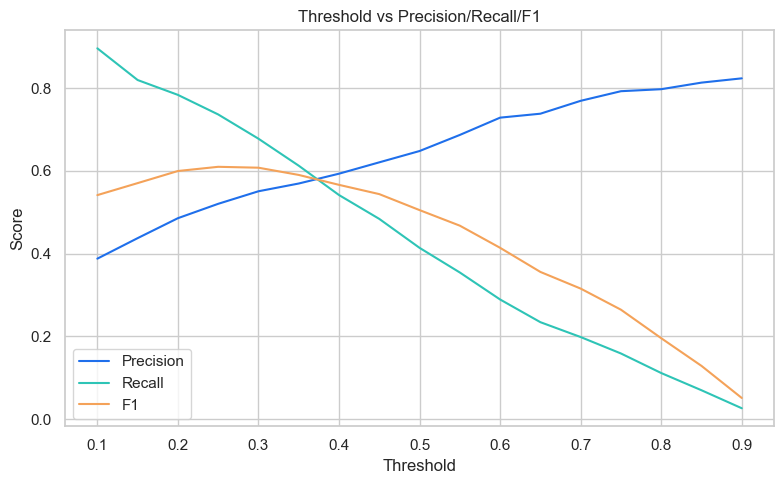

Higher thresholds increase precision but reduce recall. Threshold 0.25 was selected to satisfy precision/recall >= 0.30 while maximizing F1.

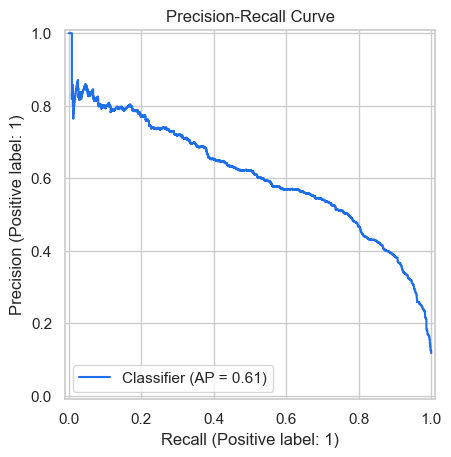

Precision-recall trade-off across thresholds for the selected model.

In [7]:
# Select best tuned model by ROC-AUC on test set
best_tuned_name = max(after_metrics, key=lambda k: after_metrics[k]["ROC_AUC"])
best_tuned_model = tuned_models[best_tuned_name]
print("Best tuned model for thresholding:", best_tuned_name)

y_prob = best_tuned_model.predict_proba(Xte_without)[:, 1]
roc_auc = roc_auc_score(yte_without, y_prob)

thresholds = np.arange(0.10, 0.91, 0.05)
rows = []
for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yte_without, y_pred).ravel()
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(yte_without, y_pred),
        "precision": precision_score(yte_without, y_pred, zero_division=0),
        "recall": recall_score(yte_without, y_pred, zero_division=0),
        "f1": f1_score(yte_without, y_pred, zero_division=0),
        "roc_auc": roc_auc,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn
})

threshold_df = pd.DataFrame(rows)
display(threshold_df)

# Pick the threshold with the best F1 among those meeting precision/recall >= 0.30
eligible = threshold_df[(threshold_df["precision"] >= 0.30) & (threshold_df["recall"] >= 0.30)]
if eligible.empty:
    best_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
else:
    best_row = eligible.sort_values("f1", ascending=False).iloc[0]

final_threshold = float(best_row["threshold"])
print("Selected threshold:", final_threshold)

# Plot threshold curves
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision/Recall/F1")
plt.legend()
plt.tight_layout()
plt.show()
display(Markdown(
    f"Higher thresholds increase precision but reduce recall. Threshold {final_threshold:.2f} "
    "was selected to satisfy precision/recall >= 0.30 while maximizing F1."
))

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(yte_without, y_prob)
plt.title("Precision-Recall Curve")
plt.show()
display(Markdown("Precision-recall trade-off across thresholds for the selected model."))


## Final Model Selection and Saving
We deploy the best tuned model from the **no-duration** scenario for pre-campaign prediction, and save artifacts for reproducibility.

In [8]:
# Save model and preprocessing artifacts
trained_dir = project_root / "trained_models"
transformer_dir = project_root / "saved_transformers"
trained_dir.mkdir(parents=True, exist_ok=True)
transformer_dir.mkdir(parents=True, exist_ok=True)

# Best model for pre-campaign prediction (no-duration)
deployment_model = best_tuned_model
joblib.dump(deployment_model, trained_dir / "best_model_without_duration.joblib")

# Save post-call analysis model (with duration)
joblib.dump(trained_with[best_with], trained_dir / "best_model_with_duration.joblib")

# Save preprocessors and feature list for no-duration scenario
preprocessor_no_duration = build_preprocessor(Xtr_without)
preprocessor_no_duration.fit(Xtr_without)
feature_list_no_duration = list(Xtr_without.columns)

joblib.dump(preprocessor_no_duration, transformer_dir / "preprocessor_no_duration.joblib")
joblib.dump(feature_list_no_duration, transformer_dir / "feature_list_no_duration.joblib")

# Save final threshold
joblib.dump(final_threshold, transformer_dir / "final_threshold.pkl")

# Save feature importance (embedded method, XGBoost) for the EDA dashboard
xgb_pipeline_final = tuned_models["XGBoost"]
feature_names_out = [
    f.split("__", 1)[-1] for f in xgb_pipeline_final.named_steps["preprocessor"].get_feature_names_out()
]
feature_importance_df = pd.DataFrame({
    "feature": feature_names_out,
    "importance": xgb_pipeline_final.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)
feature_importance_df.to_csv(transformer_dir / "feature_importance.csv", index=False)

print("Artifacts saved.")

Artifacts saved.
